# **TP — Implémentation d’un Mini Réseau de Neurones avec NumPy**
> **But :** ce TP a pour objectif d’introduire, à l’aide de **NumPy** et **Matplotlib**, les bases de l’implémentation d’un mini réseau de neurones *from scratch*.  
> Dans une première partie, il s’agit d’implémenter et de visualiser plusieurs **fonctions d’activation** (ReLU, Sigmoid, Tanh, LeakyReLU, puis Softplus et ELU), en produisant :
> 1. un **tracé comparatif** des fonctions sur une même figure,
> 2. une **grille de sous-figures** pour visualiser chaque fonction séparément.
>
> Dans une deuxième partie, il s’agit d’implémenter un **mini réseau de neurones 2 → 3 → 1** en NumPy pour apprendre la fonction **XOR**, en détaillant :
> - la **propagation avant**,
> - la **fonction de perte**,
> - la **rétropropagation des gradients**,
> - l’**entraînement par descente de gradient**,
> - puis l’extension à un **dataset XOR bruité** avec données perturbées et labels erronés.
>
> Enfin, le TP vise à évaluer le modèle appris à l’aide de métriques de classification telles que :
> - **Accuracy**
> - **Precision**
> - **Recall**
> - **F1-score**
> - **Matrice de confusion**
> - **Courbe ROC** et **AUC**

## 1) Objectifs pédagogiques

A l’issue de ce TP, l’étudiant devra être capable de :
- implémenter des fonctions d’activation
- manipuler les produits matriciels NumPy
- comprendre les shapes des matrices
- implémenter un réseau de neurones 2 → 3 → 1
- implémenter la backpropagation
- entraîner un modèle pour apprendre XOR
- évaluer un modèle avec accuracy, precision, recall, F1
- analyser un modèle avec matrice de confusion et ROC curve
- comprendre l’effet du bruit dans les données

---

## 2) Pré-requis

- Python 3.x
- Bibliothèques : `numpy`, `matplotlib`, `scipy`

---

## Partie A : Mini Réseau de Neurones pour XOR
### I — Mise en place

#### I.1. Imports et création du dataset (vecteur `x`)

##### ✅ À faire
- Importer `numpy` et `matplotlib.pyplot`
- Créer `x` avec **600 points** entre `-3` et `3`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 600 points entre -3 et 3
x = np.linspace(-3, 3, 600)

#### I.2. Dictionnaires des fonctions d’activation et de leurs dérivées

##### ✅ À faire

Définir deux dictionnaires :

- `activations` : contenant les **fonctions d’activation**
- `d_activations` : contenant leurs **dérivées**, nécessaires pour la **backpropagation**

Ces fonctions sont utilisées dans les **réseaux de neurones** pour introduire de la **non-linéarité** dans le modèle.

---

### 1️⃣ ReLU (Rectified Linear Unit)

Fonction d’activation :

$$
f(x)=\max(0,x)
$$

Dérivée :

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
0 & \text{sinon}
\end{cases}
$$

Cette fonction est très utilisée dans les réseaux profonds car :
- elle est **simple**
- elle **accélère l’apprentissage**

---

### 2️⃣ Sigmoid

Fonction d’activation :

$$
f(x)=\frac{1}{1+e^{-x}}
$$

Cette fonction transforme toute valeur réelle en **probabilité dans l’intervalle [0,1]**.

Elle est donc souvent utilisée pour la **sortie des modèles de classification binaire**.

---

#### Forme stable numériquement

Pour éviter les problèmes d’overflow lorsque \(x\) est très grand en valeur absolue :

$$
f(x)=
\begin{cases}
\dfrac{1}{1+e^{-x}} & \text{si } x \ge 0 \\
\dfrac{e^x}{1+e^x} & \text{sinon}
\end{cases}
$$

---

#### Dérivée

Si :

$$
s=f(x)
$$

alors :

$$
f'(x)=s(1-s)
$$

Cette forme est très pratique car elle utilise **la sortie déjà calculée**.

---

### 3️⃣ Tanh (Hyperbolic Tangent)

Fonction d’activation :

$$
f(x)=\tanh(x)
$$

Elle renvoie des valeurs dans l’intervalle :

$$
(-1,1)
$$

Elle est souvent préférée à sigmoid dans les **couches cachées** car elle est **centrée autour de zéro**.

---

#### Dérivée

Si :

$$
a=\tanh(x)
$$

alors :

$$
f'(x)=1-a^2
$$

---

### 4️⃣ LeakyReLU

Contrairement à ReLU, cette fonction garde une **petite pente dans la zone négative**.

Avec \(a=0.1\) :

$$
f(x)=
\begin{cases}
x & \text{si } x>0 \\
ax & \text{sinon}
\end{cases}
$$

---

#### Dérivée

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
a & \text{sinon}
\end{cases}
$$

---

### 🔎 Remarque importante pour l’implémentation

Dans le **backpropagation**, certaines dérivées sont calculées à partir de la **sortie de la fonction d’activation** plutôt qu’à partir de \(x\).

Exemples :

- pour **Sigmoid** :

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

- pour **Tanh** :

$$
\tanh'(x)=1-\tanh^2(x)
$$

Ainsi, dans le code Python, on peut écrire les dérivées en fonction de la **sortie déjà calculée**, ce qui évite de recalculer l’activation.

In [2]:
# --- fonctions d'activations ---
activations = {
    "Relu": lambda x: np.maximum(0, x),
    "Sigmoid": lambda x: 1 / (1 + np.exp(-x)),
    "Sigmoid_stable": lambda x: np.where(x >= 0, 1 / (1 + np.exp(-x)), np.exp(x) / (1 + np.exp(x))),
    "Tanh": lambda x: np.tanh(x),
    "LeakyRelu": lambda x: np.where(x > 0, x, 0.1 * x)
}

# --- dérivées ---
# On spécifie si la dérivée prend en paramètre l'input "z" (x) ou l'output "out" (activation)
d_activations = {
    "Relu": {"type": "z", "func": lambda x: np.where(x > 0, 1, 0)},
    "Sigmoid": {"type": "out", "func": lambda out: out * (1 - out)},
    "Sigmoid_stable": {"type": "out", "func": lambda out: out * (1 - out)},
    "Tanh": {"type": "out", "func": lambda out: 1 - out**2},
    "LeakyRelu": {"type": "z", "func": lambda x: np.where(x > 0, 1, 0.1)}
}

---
#### I.4. Dictionnaires style des courbes (couleurs des courbes et marqueurs) : 
##### ✅ A faire :
- utiliser une couleur distincte par courbe :
    Codes couleurs : `["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]`
- utiliser un marqueur distinct  par courbe :
    Codes marqueurs : 
    - `"o"` : cercle  
    - `"s"` : carré  
    - `"^"` : triangle haut  
    - `"v"` : triangle bas  
    - `"D"` : losange  
    - `"x"` | `"+"` : croix  
    - `"*"` : étoile  
    - `"."` : point  

In [3]:
couleurs = {
    "Relu": "tab:blue",
    "Sigmoid": "tab:orange",
    "Sigmoid_stable": "tab:cyan",
    "Tanh": "tab:green",
    "LeakyRelu": "tab:red"
}

markers = {
    "Relu": "o",
    "Sigmoid": "s",
    "Sigmoid_stable": "p",
    "Tanh": "^",
    "LeakyRelu": "D"
}

---
### II. Tracé comparatif sur 1 seule figure
#### A Faire :
Tracer les 4 activations sur **le même graphique**, avec :
- `plot`
- `label`, `color`, `marker`, `markersize`, `markevery`
- `title`, `xlabel`, `ylabel`, `grid`, `legend`, `show`

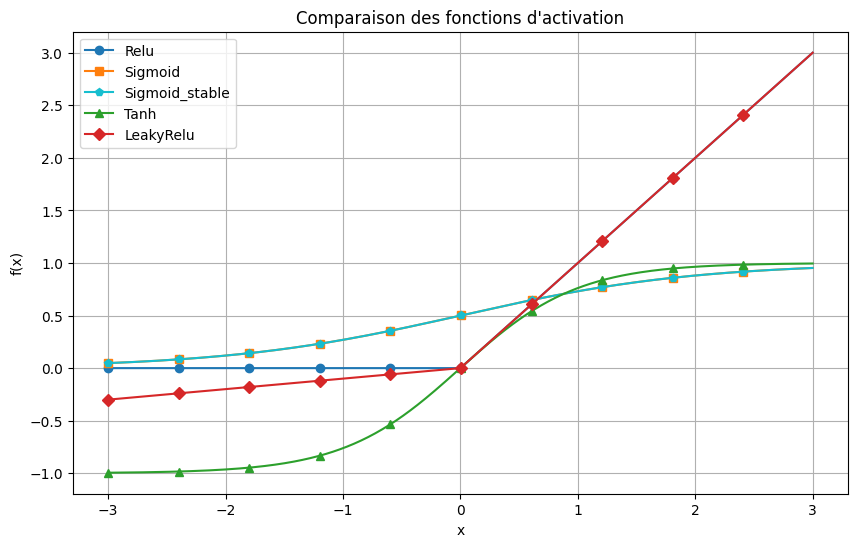

In [4]:
plt.figure(figsize=(10, 6))

for nom, func in activations.items():
    plt.plot(x, func(x), label=nom, color=couleurs[nom], marker=markers[nom], markersize=6, markevery=60)

plt.title("Comparaison des fonctions d'activation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

---
### III. subplots(2x2) pour le Tracé de chaque fonction sur une sous figure 
#### ✅ A faire :
- Créer une grille 2×2 avec `plt.subplots(2,2, ...)` avec : `figsize`, `sharex`, `sharey`
- Aplatir `axes` avec `axes.ravel()`
- Tracer une activation par subplot avec `ax.plot(...)`
- Ajouter titre, labels, grille, légende dans chaque axe
- Utiliser `plt.tight_layout()` et `plt.show()` pour ajuster et afficher la figure


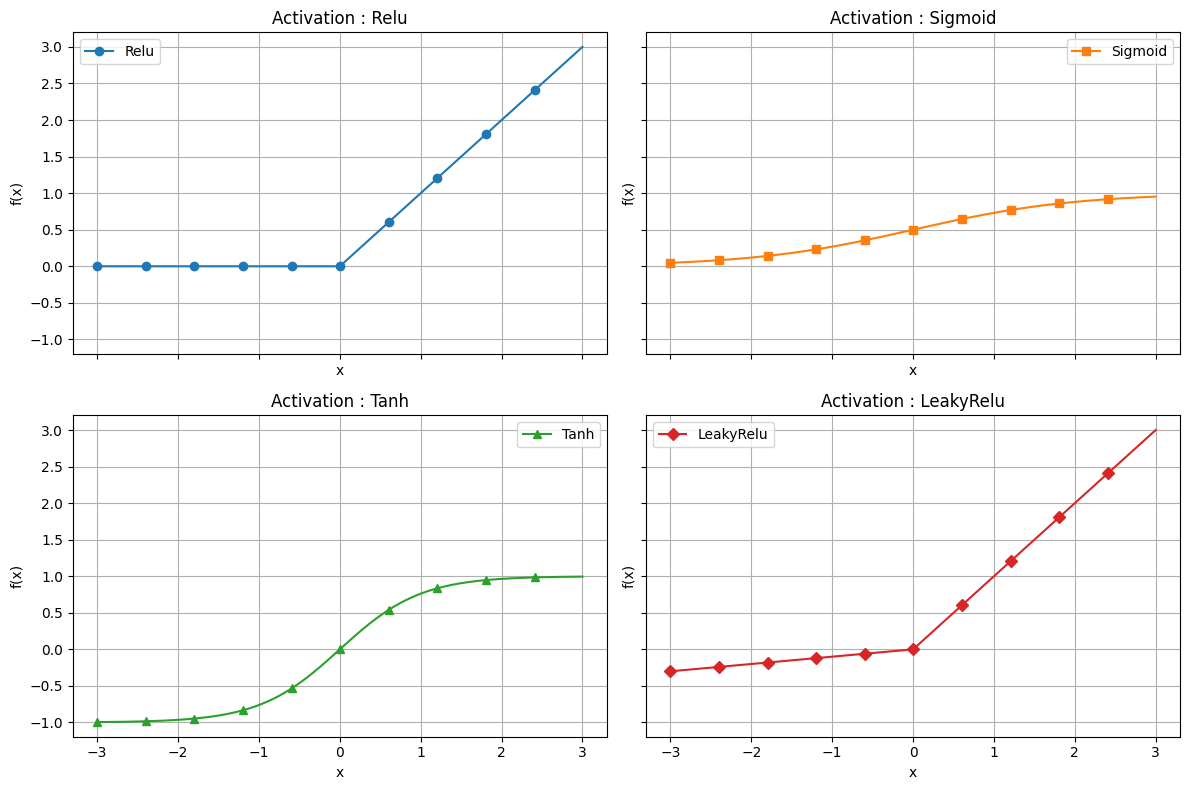

In [5]:
# Grille 2x2.
fonctions_a_tracer = ["Relu", "Sigmoid", "Tanh", "LeakyRelu"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.ravel()

for i, nom in enumerate(fonctions_a_tracer):
    ax = axes[i]
    ax.plot(x, activations[nom](x), label=nom, color=couleurs[nom], marker=markers[nom], markersize=6, markevery=60)
    ax.set_title(f"Activation : {nom}")
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

---
### IV. Extension 1 — Ajout de deux fonctions d’activation supplémentaires

#### IV.1. Ajouter les fonctions d’activation suivantes :

---

### 5️⃣ Softplus

Fonction d’activation :

$$
f(x)=\ln(1+e^x)
$$

Cette fonction est une **version lisse de ReLU**.  
Elle est continue et dérivable partout.

---

#### Dérivée (par rapport à l’input)

$$
f'(x)=\frac{e^x}{1+e^x}
$$

On reconnaît la **fonction sigmoid** :

$$
f'(x)=\sigma(x)
$$

---

#### Dérivée (forme pratique pour l’implémentation)

Dans l’implémentation NumPy, on peut calculer la dérivée directement avec :

$$
f'(x)=\sigma(x)
$$


### 6️⃣ ELU (Exponential Linear Unit)

Avec $ \alpha = 1 $.

#### Fonction d’activation

$$
f(x)=
\begin{cases}
x & \text{si } x>0 \\
\alpha(e^x-1) & \text{sinon}
\end{cases}
$$

---

#### Dérivée (par rapport à l’input)

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
\alpha e^x & \text{sinon}
\end{cases}
$$

---

#### Dérivée (forme pratique en fonction de l’output)

Si

$$
a=f(x)
$$

alors, pour $x \le 0$ :

$$
a=\alpha(e^x-1)
$$

donc :

$$
f'(x)=a+\alpha
$$

Ainsi :

$$
f'(x)=
\begin{cases}
1 & \text{si } x>0 \\
a+\alpha & \text{si } x\le0
\end{cases}
$$

Cette forme peut être utilisée si l’on dispose déjà de l’output de la fonction ELU.

---

### 🔎 Remarque pédagogique

Dans les réseaux de neurones, les dérivées sont souvent exprimées en fonction de la **sortie de l’activation** pour éviter de recalculer l’activation.

Exemples déjà utilisés dans ce TP :

Exemples déjà utilisés dans ce TP :

| Fonction | $f(x)$ | Dérivée utilisée |
|----------|--------|------------------|
| Sigmoid | $f(x)=\dfrac{1}{1+e^{-x}}$ | $f'(x)=s(1-s)$ avec $s=f(x)$ |
| Tanh | $f(x)=\tanh(x)$ | $f'(x)=1-a^2$ avec $a=f(x)$ |
| ReLU | $f(x)=\max(0,x)$ | dépend directement de $x$ |
| LeakyReLU | $f(x)=\begin{cases}x & \text{si } x>0 \\ ax & \text{sinon}\end{cases}$ | dépend directement de $x$ |
| Softplus | $f(x)=\ln(1+e^x)$ | $f'(x)=\sigma(x)$ |
| ELU | $f(x)=\begin{cases}x & \text{si } x>0 \\ \alpha(e^x-1) & \text{sinon}\end{cases}$ | $f'(x)=a+\alpha$ si $x\le0$ |

In [6]:
# Ajout des activations
activations["Softplus"] = lambda x: np.log(1 + np.exp(x))
activations["ELU"] = lambda x: np.where(x > 0, x, 1.0 * (np.exp(x) - 1))

# Ajout des dérivées
# Softplus' = Sigmoid. On l'évalue par rapport à "z" (l'input)
d_activations["Softplus"] = {"type": "z", "func": lambda x: activations["Sigmoid_stable"](x)}
# ELU' dépend de l'input pour la condition x>0 et de l'output. On va la coder par rapport à "z" pour plus de simplicité ici.
d_activations["ELU"] = {"type": "z", "func": lambda x: np.where(x > 0, 1, 1.0 * np.exp(x))}

# Ajout du style
couleurs["Softplus"] = "tab:purple"
couleurs["ELU"] = "tab:brown"
markers["Softplus"] = "*"
markers["ELU"] = "v"

---
#### IV.2. tracé comparatif des courbes des fonctions d'activation et de leur dérivées :
##### ✅ La fonction devra
- créer une figure en deux sous graphes avec `plt.subplots(2, 1, ...)`
- Pour chaque sous graphe, tracer  :
  - les fonctions `activations`
  - les fonctions dérivées 
- pour chaque sous-graphe, tracer la courbe avec :
  - `plot`, `label`, `color`, `marker`, `markersize`, `markevery`
- ajouter :
  - `xlabel`, `ylabel`, `legend`, `grid`
- masquer automatiquement les sous-graphes inutilisés si le nombre total de cases est supérieur au nombre de fonctions à tracer

---

##### ✅ Cas particulier des dérivées
Dans le dictionnaire `d_activations`, chaque dérivée est associée à une information indiquant si elle doit être calculée :

- à partir de l’**input** (`"z"`)
- ou à partir de l’**output** (`"out"`)

Ainsi :

- si la dérivée est définie par rapport à `"z"`, on l’évalue directement sur `x`
- si la dérivée est définie par rapport à `"out"`, on doit :
  1. calculer d’abord l’activation correspondante
  2. puis appliquer la dérivée à cette sortie

---

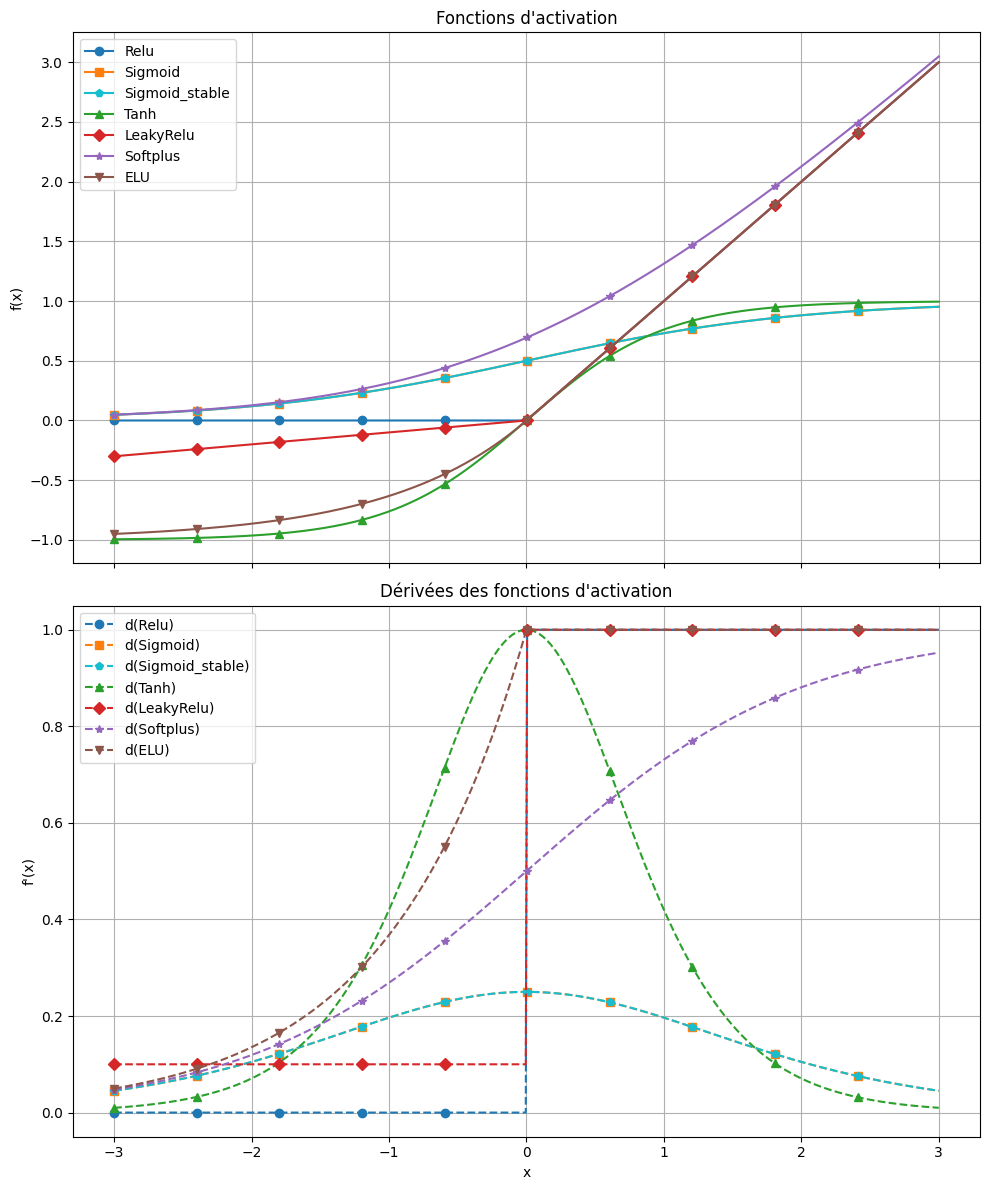

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

# Graphique des activations
for nom, func in activations.items():
    axes[0].plot(x, func(x), label=nom, color=couleurs[nom], marker=markers[nom], markersize=6, markevery=60)
axes[0].set_title("Fonctions d'activation")
axes[0].set_ylabel("f(x)")
axes[0].grid(True)
axes[0].legend()

# Graphique des dérivées
for nom, d_info in d_activations.items():
    if d_info["type"] == "z":
        y_prime = d_info["func"](x)
    else: # type == "out"
        out = activations[nom](x)
        y_prime = d_info["func"](out)
        
    axes[1].plot(x, y_prime, label=f"d({nom})", color=couleurs[nom], marker=markers[nom], markersize=6, markevery=60, linestyle="--")

axes[1].set_title("Dérivées des fonctions d'activation")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f'(x)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# TODO

#### IV.3. Tracé comparatif par une Fonction `sub_tracer(rows, cols, mode="activation")`

##### ✅ À faire
Ecrire une fonction `sub_tracer(rows, cols, mode="activation")` permettant de tracer automatiquement, dans une grille de sous-graphes :

- les **fonctions d’activation**,
- ou leurs **dérivées**,
- ou **les deux** successivement.

---

##### ✅ Paramètres
- `rows` : nombre de lignes de la grille
- `cols` : nombre de colonnes de la grille
- `mode` : type de tracé à réaliser, avec l’une des valeurs suivantes :
  - `"activation"` : trace uniquement les **fonctions d’activation**
  - `"derivee"` : trace uniquement les **fonctions dérivées**
  - `"both"` : trace d’abord les **fonctions d’activation**, puis les **dérivées**

---


##### ✅ Appels attendus

```python
sub_tracer(4, 2, mode="activation")

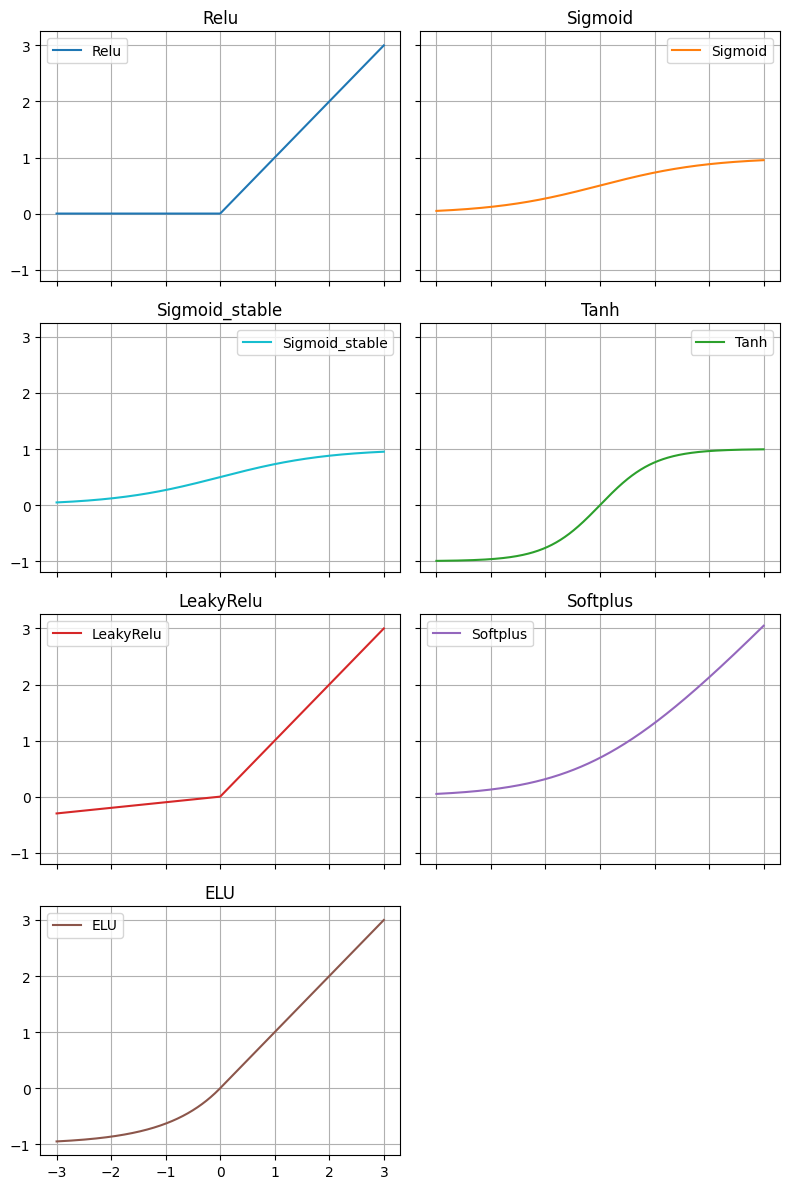

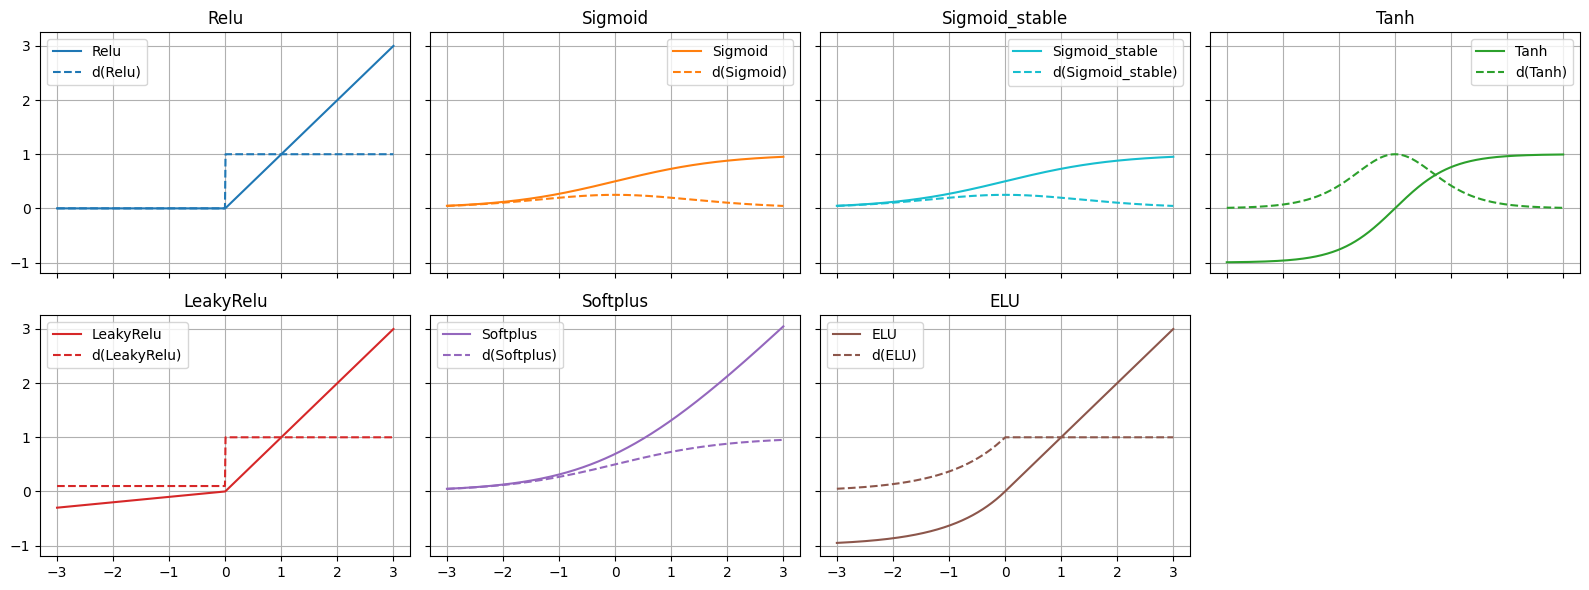

In [9]:
def sub_tracer(rows, cols, mode="both"):
    n_funcs = len(activations)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True, sharey=True)
    axes = axes.ravel()
    
    for i, nom in enumerate(activations.keys()):
        # Sécurité pour ne pas déborder du nombre de graphes disponibles
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        if mode in ["activation", "both"]:
            ax.plot(x, activations[nom](x), label=nom, color=couleurs[nom], linestyle="-")
            
        if mode in ["derivee", "both"]:
            d_info = d_activations[nom]
            y_prime = d_info["func"](x) if d_info["type"] == "z" else d_info["func"](activations[nom](x))
            ax.plot(x, y_prime, label=f"d({nom})", color=couleurs[nom], linestyle="--")
            
        ax.set_title(nom)
        ax.grid(True)
        ax.legend()
        
    # Masquer les sous-graphes vides s'il y en a
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Tests
sub_tracer(4, 2, mode="activation")
sub_tracer(2, 4, mode="both") # (2x4 pour englober toutes nos 7 fonctions proprement)

---
### V. Extension 2 - Implémentation Mini Réseau de Neurones (2 → 3 → 1) en NumPy pour l'apprentissage de XOR
#### V.1. Comprendre l’exemple XOR ($\oplus$)

##### a) Définition du problème XOR
On considère deux entrées binaires $x_1, x_2$. La sortie $y$ vaut 1 **si les deux entrées sont différentes**, sinon 0.

| $x_1$ | $x_2$ | $y = x_1 \oplus x_2$ |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

##### b) Pourquoi XOR ?
- Un modèle **linéaire** (sans couche cachée) ne peut pas résoudre XOR : le problème est **non-linéairement séparable**.
- En ajoutant une **couche cachée** + une **activation non-linéaire**, le réseau peut apprendre une transformation qui rend XOR résoluble.

##### c) Schéma du mini-réseau (2 → 3 → 1)
<img src="reseau_xor_2_3_1_poids_wij.png" height="200px">


---

#### V.2. Préparer le mini-dataset de la fonction XOR


In [10]:
x_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

print(x_xor.shape)
print(y_xor.shape)

(4, 2)
(4, 1)


---
#### V.3. Visualiser les points XOR

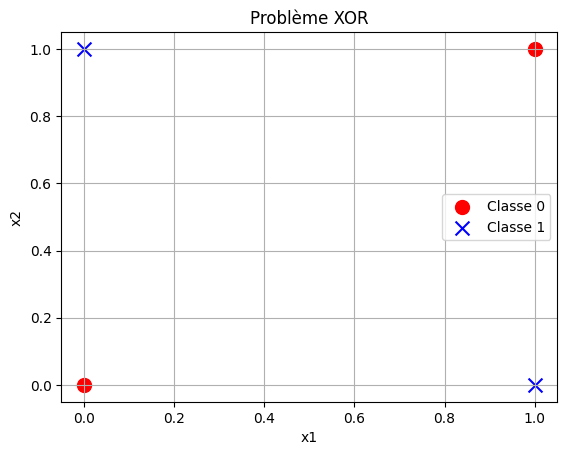

In [11]:
plt.scatter(x_xor[y_xor[:,0]==0][:,0], x_xor[y_xor[:,0]==0][:,1], color='red', marker='o', s=100, label='Classe 0')
plt.scatter(x_xor[y_xor[:,0]==1][:,0], x_xor[y_xor[:,0]==1][:,1], color='blue', marker='x', s=100, label='Classe 1')
plt.title("Problème XOR")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

#### V.4. Initialisation des paramètres (W1, b1, W2, b2)

##### ✅ Contraintes de dimensions (shapes)

Pour un lot de **N** exemples (*batch*), un réseau **2 → 3 → 1** implique :

- $X \in \mathbb{R}^{N \times 2}$
- $W_1 \in \mathbb{R}^{2 \times 3}$,  $b_1 \in \mathbb{R}^{3}$ *(ou $1 \times 3$)*
- $W_2 \in \mathbb{R}^{3 \times 1}$,  $b_2 \in \mathbb{R}^{1}$ *(ou $1 \times 1$)*

---

##### ✅ Shapes à chaque étape (forward)

1) **Couche 1 (linéaire)**  
$
Z_1 = XW_1 + b_1 \quad \Rightarrow \quad Z_1 \in \mathbb{R}^{N \times 3}
$

2) **Activation 1**  
$
A_1 = \sigma_1(Z_1) \quad \Rightarrow \quad A_1 \in \mathbb{R}^{N \times 3}
$

3) **Couche 2 (linéaire)**  
$
Z_2 = A_1W_2 + b_2 \quad \Rightarrow \quad Z_2 \in \mathbb{R}^{N \times 1}
$

4) **Activation 2 (sortie)**  
$
\hat{y} = \sigma_2(Z_2) \quad \Rightarrow \quad \hat{y} \in \mathbb{R}^{N \times 1}
$

---

#### 🔎 Cas XOR

Pour XOR, on a **$N = 4$**, donc :

- $X : (4, 2)$
- $Z_1, A_1 : (4, 3)$
- $Z_2, \hat{y} : (4, 1)$    

---

In [12]:
# Initialisation avec une graine pour rendre les résultats reproductibles
np.random.seed(42)

data_config = {
    "N": x_xor.shape[0],
    "input_dim": x_xor.shape[1]
}
hyperparams = {
    "hidden_dim": 3,
    "output_dim": 1,
    "learning_rate": 0.8,
    "epochs": 4000
}

W1 = np.random.randn(data_config["input_dim"], hyperparams["hidden_dim"])
b1 = np.zeros((1, hyperparams["hidden_dim"]))
W2 = np.random.randn(hyperparams["hidden_dim"], hyperparams["output_dim"])
b2 = np.zeros((1, hyperparams["output_dim"]))

print("Shape W1:", W1.shape)
print("Shape b1:", b1.shape)
print("Shape W2:", W2.shape)
print("Shape b2:", b2.shape)

Shape W1: (2, 3)
Shape b1: (1, 3)
Shape W2: (3, 1)
Shape b2: (1, 1)


#### V.5. Choix des activations (une par couche)

##### ✅ Fonctions Activations recommandées et dérivées utiles

- **Couche cachée** : `tanh` *(ou `relu` ou `leaky-relu`)*
- **Couche de sortie** : `sigmoid` *(classification binaire)*

> Rappel : `sigmoid` renvoie une probabilité dans \([0,1]\), ce qui convient à une sortie binaire (0/1).

---

##### ✅ Dérivées (formes pratiques)

Dans le **backprop**, on utilise souvent une forme pratique des dérivées **en fonction de la sortie** (quand on a déjà calculé l’activation).

- Si $a = \tanh(z)$ alors :
$
\tanh'(z)=1-a^2
$

- Si $s = \sigma(z)$ alors :
$
\sigma'(z)=s(1-s)
$

---


##### 🧠 Cellule Python (à compléter)

In [13]:
act_hid = activations["Tanh"]
act_out = activations["Sigmoid_stable"]
d_act_hid = d_activations["Tanh"]["func"]
d_act_out = d_activations["Sigmoid_stable"]["func"]

---
#### V.6. Propagation avant (Forward pass)

##### ✅ Formules

Pour un réseau **2 → 3 → 1** :

###### 1) Pré-activation cachée (Couche cachée (linéaire))
$
Z_1 = XW_1 + b_1
$

- `X @ W1` réalise le **produit matriciel**.
- `+ b1` se fait par **broadcasting** sur les \(N\) lignes de \(Z_1\).

---

###### 2) Activation cachée
$
A_1 = \tanh(Z_1)
$

---

###### 3) Pré-activation de sortie (Couche de sortie (linéaire))
$
Z_2 = A_1W_2 + b_2
$

---

###### 4) Activation de sortie (Sortie probabiliste)
$
\hat{y} = \sigma(Z_2)
$

---

##### 🧠 Cellule Python (à compléter)


In [14]:
def forward(x, W1, b1, W2, b2, act_hid, act_out):
    Z1 = np.dot(x, W1) + b1
    A1 = act_hid(Z1)
    Z2 = np.dot(A1, W2) + b2
    y_hat = act_out(Z2)
    cache = (x, Z1, A1, Z2, y_hat)
    return y_hat, cache

y_hat, cache = forward(x_xor, W1, b1, W2, b2, act_hid, act_out)
print(y_hat)

[[0.5       ]
 [0.79694852]
 [0.58724878]
 [0.74411879]]


---
#### V.7. Fonction de perte \(L\) (MSE)

On utilise la **MSE** (*Mean Squared Error*) :

$
L = \frac{1}{N}\sum_{i=1}^{N}\left(\hat{y}_i - y_i\right)^2
$

- $N$ : nombre d’exemples
- $y$ : valeurs réelles (labels)
- $\hat{y}$ : prédictions du modèle

---

#### 🧠 Cellule Python (à compléter)

In [15]:
def mse(y_hat, y):
    return np.mean((y_hat - y) ** 2)

print("Loss:", mse(y_hat, y_xor))

Loss: 0.25382656025001427


#### V.8. Backpropagation (calcul détaillé)

##### ✅ Idée générale

On veut calculer les **gradients** des paramètres du réseau :

- $dW_2 = \dfrac{\partial L}{\partial W_2}$, $\;db_2 = \dfrac{\partial L}{\partial b_2}$
- $dW_1 = \dfrac{\partial L}{\partial W_1}$, $\;db_1 = \dfrac{\partial L}{\partial b_1}$

---

##### Etape 1 — Gradient de la loss par rapport à $\hat{y}$

Pour la MSE :
$
L = \frac{1}{N}\sum_{i=1}^{N}(\hat{y}_i - y_i)^2
$

Donc :
$
\frac{\partial L}{\partial \hat{y}} = \frac{2(\hat{y}-y)}{N}
$

En code : `dY`.

---

##### Etape 2 — Passer de $\hat{y}$ à $Z_2$ (sortie sigmoid)

$
\hat{y} = \sigma(Z_2)
\Rightarrow
dZ_2 = dY \odot \sigma'(Z_2)
$

Or :
$
\sigma'(Z_2) = \hat{y}(1-\hat{y})
$

Donc :
$
dZ_2 = dY \odot \hat{y}(1-\hat{y})
$

---

##### Etape 3 — Gradients de $W_2$ et $b_2$

Comme :
$
Z_2 = A_1W_2 + b_2
$

Alors :
$
dW_2 = A_1^T dZ_2
\qquad
db_2 = \sum_{i=1}^{N} dZ_2^{(i)}
$

- `A1.T @ dZ2` est un **produit matriciel**
- `np.sum(..., axis=0)` cumule sur les $N$ exemples

---

##### Etape 4 — Propager vers la couche cachée

D’abord :
$
dA_1 = dZ_2 W_2^T
$

Puis comme :
$
A_1 = \tanh(Z_1)
$

On utilise :
$
\tanh'(Z_1) = 1 - A_1^2
$

Donc :
$
dZ_1 = dA_1 \odot (1 - A_1^2)
$

---

##### Etape 5 — Gradients de \(W_1\) et \(b_1\)

Comme :
$
Z_1 = XW_1 + b_1
$

Alors :
$
dW_1 = X^T dZ_1
\qquad
db_1 = \sum_{i=1}^{N} dZ_1^{(i)}
$

---

#### V.9. Boucle d’entraînement (Gradient Descent)

##### ✅ Mise à jour des paramètres

$
W \leftarrow W - \eta\, dW
\qquad
b \leftarrow b - \eta\, db
$

où $\eta$ est le **learning rate**.

---

##### 🧠 Cellule Python (complète)

In [16]:
def train(x, y, W1, b1, W2, b2, lr=0.8, epochs=4000, f_act_hid=act_hid, f_act_out=act_out, d_f_act_hid=d_act_hid, d_f_act_out=d_act_out):
    losses = []

    for epoch in range(epochs):
        # ---------- Forward ----------
        y_hat, (xc, Z1, A1, Z2, yhc) = forward(x, W1, b1, W2, b2, f_act_hid, f_act_out)

        # ---------- Loss ----------
        L = mse(y_hat, y)
        losses.append(L)

        # ---------- Backprop ----------
        N = y.shape[0]

        # dL/dy_hat
        dY = 2 * (y_hat - y) / N

        # y_hat = sigmoid(Z2) -> dérivée fonction de l'output
        dZ2 = dY * d_f_act_out(y_hat)

        # dW2, db2
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        # propagate to hidden
        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * d_f_act_hid(A1)

        # dW1, db1
        dW1 = np.dot(x.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # ---------- Update ----------
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 400 == 0:
            print(f"epoch={epoch:4d}  loss={L:.6f}")

    return W1, b1, W2, b2, losses

# On utilise des copies pour ne pas écraser l'initialisation aléatoire d'origine
W1t, b1t, W2t, b2t, losses = train(x_xor, y_xor, W1.copy(), b1.copy(), W2.copy(), b2.copy())

y_pred, _ = forward(x_xor, W1t, b1t, W2t, b2t, act_hid, act_out)
print("\nProbas:\n", y_pred)
print("Classes:\n", (y_pred >= 0.5).astype(int))

epoch=   0  loss=0.253827
epoch= 400  loss=0.003730
epoch= 800  loss=0.001449
epoch=1200  loss=0.000880
epoch=1600  loss=0.000627
epoch=2000  loss=0.000486
epoch=2400  loss=0.000395
epoch=2800  loss=0.000333
epoch=3200  loss=0.000288
epoch=3600  loss=0.000253

Probas:
 [[0.00578712]
 [0.98399073]
 [0.98384036]
 [0.01873163]]
Classes:
 [[0]
 [1]
 [1]
 [0]]


#### V.10. Courbe de convergence de la loss

La courbe de convergence permet de visualiser l’évolution de la **fonction de perte (MSE)** au fil des **epochs**.  
Une loss qui diminue progressivement indique que l’entraînement converge.

---

##### 🧠 Cellule Python

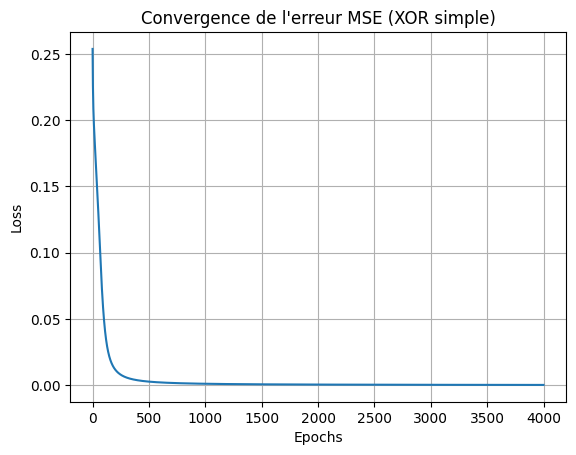

In [17]:
plt.plot(losses)
plt.title("Convergence de l'erreur MSE (XOR simple)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Partie B -  Extension : Dataset bruité + Evaluation du modèle

Dans cette partie, nous allons :

1. générer un **dataset XOR bruité**
2. séparer les données en **train / test**
3. entraîner le **mini réseau de neurones**
4. calculer les **prédictions**
5. évaluer le modèle avec :
   - accuracy
   - precision
   - recall
   - F1-score
   - matrice de confusion
   - courbe ROC et AUC

Cette partie simule une situation proche d'un **problème réel de classification supervisée**.

---

### I — Génération d’un dataset XOR bruité

#### I.1. Motivation

Dans un problème réel :

- les données sont dupliquées 
- les données contiennent du **bruit**
- certaines **étiquettes peuvent être erronées**

Nous allons donc modifier le dataset XOR original :

| x1 | x2 | y |
|----|----|---|
|0|0|0|
|0|1|1|
|1|0|1|
|1|1|0|

- En Dupliquant les données : répeter chaque coin `n` fois,
- En perturbant les données dupliquées : Deux types de perturbations seront ajoutés :

##### **Bruit sur les features**

On ajoute un bruit gaussien :

$
X_{bruit} = X + \epsilon
$

avec :

$
\epsilon \sim \mathcal{N}(0,\sigma^2)
$ Où  $\sigma = $ l'écart-type

##### **Labels erronés**

Avec une probabilité $p$, on inverse les labels :

$
y = 1 - y
$

---

#### I.2. Implémentation

In [18]:
def make_noisy_xor(n=10, noise=0.08, flip=0.05, seed=0):
    np.random.seed(seed)
    
    # Base XOR
    X_base = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    Y_base = np.array([[0], [1], [1], [0]])
    
    # Duplication
    X = np.repeat(X_base, n, axis=0).astype(float)
    Y = np.repeat(Y_base, n, axis=0)
    
    # Bruit gaussien
    X += np.random.normal(0, noise, X.shape)
    
    # Labels erronés
    flip_mask = np.random.rand(Y.shape[0], 1) < flip
    Y[flip_mask] = 1 - Y[flip_mask]
    
    # Mélange
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    
    return X[indices], Y[indices]

x_noisy, y_noisy = make_noisy_xor(n=100, noise=0.15, flip=0.05)
print("Shape X bruité :", x_noisy.shape)
print("Shape Y bruité :", y_noisy.shape)

Shape X bruité : (400, 2)
Shape Y bruité : (400, 1)


#### I.3. Génération du dataset

In [19]:
x, y = make_noisy_xor(n=100, noise=0.07, flip=0.05)
print(None)
print(None)

None
None


### II — Séparation Train / Test

### II.1. Objectif

Afin d’évaluer correctement le modèle, il faut :

- ✅ entraîner le modèle sur le **train set**
- ✅ évaluer le modèle sur le **test set**

Cela permet d’estimer la **capacité de généralisation** du modèle.

#### II.2. Procédure

- mélanger les indices
- définir une proportion de test
- séparer les données

🧠 **Cellule Python**

In [20]:
def split_dataset(x, y, test_ratio=0.2, seed=0):
    np.random.seed(seed)
    indices = np.arange(x.shape[0])
    np.random.shuffle(indices)
    
    split_index = int(x.shape[0] * (1 - test_ratio))
    train_idx, test_idx = indices[:split_index], indices[split_index:]
    
    return x[train_idx], x[test_idx], y[train_idx], y[test_idx]

x_train, x_test, y_train, y_test = split_dataset(x_noisy, y_noisy)

print("x_Train size :", x_train.shape)
print("x_Test size :", x_test.shape)
print("y_Train size :", y_train.shape)
print("y_Test size :", y_test.shape)

x_Train size : (320, 2)
x_Test size : (80, 2)
y_Train size : (320, 1)
y_Test size : (80, 1)


### III — Entraînement du modèle

On réutilise la fonction `train()` définie dans la partie A.

**Rappel des étapes :**
- Forward propagation
- Calcul de la loss
- Backpropagation
- Mise à jour des poids

🧠 **Cellule Python**


epoch=   0  loss=0.266756
epoch= 400  loss=0.068277
epoch= 800  loss=0.062753
epoch=1200  loss=0.060979
epoch=1600  loss=0.059937
epoch=2000  loss=0.059156
epoch=2400  loss=0.058486
epoch=2800  loss=0.057915
epoch=3200  loss=0.057463
epoch=3600  loss=0.057113


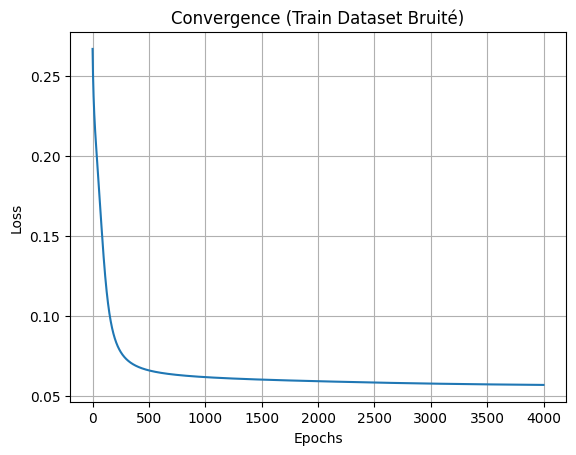

In [21]:
#  XOR : N=4, input_dim=2, hidden_dim=3, output_dim=1
data_config = {
    "N": x.shape[0],
    "input_dim": x.shape[1]
}
hyperparams = {
    "hidden_dim": 3,
    "output_dim": 1,
    "learning_rate": 0.8,
    "epochs": 4000
}
# Initialisation des poids
W1_n = np.random.randn(2, 3)
b1_n = np.zeros((1, 3))
W2_n = np.random.randn(3, 1)
b2_n = np.zeros((1, 1))

# Entraînement
W1_n, b1_n, W2_n, b2_n, losses_n = train(x_train, y_train, W1_n, b1_n, W2_n, b2_n, lr=0.5, epochs=4000)

plt.plot(losses_n)
plt.title("Convergence (Train Dataset Bruité)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### III — Prédictions du modèle

Après entraînement, on applique le modèle sur les données de test.

#### III.1 Calcul du score

Le réseau produit :

$
\hat{y} = P(y=1 \mid x)
$

C’est une **probabilité**.


### III.2. Conversion en classes

Pour obtenir une classification binaire :

$
\hat{y}=
\begin{cases}
1 & \text{si } p \ge 0.5 \\
0 & \text{sinon}
\end{cases}
$

🧠 **Cellule Python**
```python

In [22]:
y_score, _ = forward(x_test, W1_n, b1_n, W2_n, b2_n, act_hid, act_out)

threshold = 0.5
y_pred_test = (y_score >= threshold).astype(int)

print("Prédictions générées.")

Prédictions générées.


### IV. Matrice de confusion : TP, TN, FP, FN

#### IV.1. Définitions (classe positive = 1)

La matrice de confusion compare :

- les **prédictions** du modèle
- les **vraies classes**

|            | Prédit 1 | Prédit 0 |
|------------|----------|----------|
| **Réel 1** | TP       | FN       |
| **Réel 0** | FP       | TN       |

- **TP (True Positives)** : vrais **1** prédits **1**
- **TN (True Negatives)** : vrais **0** prédits **0**
- **FP (False Positives)** : vrais **0** prédits **1**
- **FN (False Negatives)** : vrais **1** prédits **0**

#### IV.1. Calcul
🧠 **Cellule Python**

In [23]:
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix(y_test, y_pred_test)
print("TP :", TP)
print("TN :", TN)
print("FP :", FP)
print("FN :", FN)

TP : 40
TN : 34
FP : 3
FN : 3


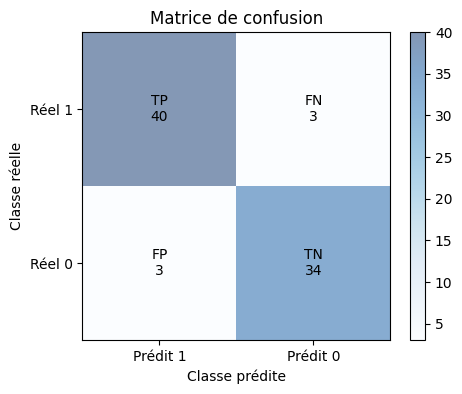

In [24]:
# Matrice de confusion
cm = np.array([[TP, FN], [FP, TN]])

# Textes
cm_txt = np.array([[f"TP\n{TP}", f"FN\n{FN}"], [f"FP\n{FP}", f"TN\n{TN}"]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", alpha=0.5)
plt.title("Matrice de confusion")
plt.colorbar()

# Étiquettes
plt.xticks([0, 1], ["Prédit 1", "Prédit 0"])
plt.yticks([0, 1], ["Réel 1", "Réel 0"])

# Affichage des valeurs
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center")

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

### V — Métriques de classification

#### **Accuracy**
$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$

#### **Precision**
$
Precision=\frac{TP}{TP+FP}
$

#### **Recall**
$
Recall=\frac{TP}{TP+FN}
$

#### **F1 Score**
$
F1=\frac{2 \cdot Precision \cdot Recall}{Precision + Recall}
$

🧠 **Cellule Python**


In [25]:
def classification_metrics(TP, TN, FP, FN):
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

accuracy, precision, recall, f1 = classification_metrics(TP, TN, FP, FN)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)
print("F1        :", f1)

Accuracy  : 0.925
Precision : 0.9302325581395349
Recall    : 0.9302325581395349
F1        : 0.9302325581395349


### VI. Courbe ROC

La courbe **ROC** (Receiver Operating Characteristic) analyse le comportement du modèle pour **différents seuils** de décision.

Pour chaque seuil \(t\) :

- convertir les probabilités en classes ($\hat{y} = 1$ si $p \ge t$, sinon 0)
- calculer $TP, TN, FP, FN$
- calculer **TPR** et **FPR**

#### VI.1. Définitions

$
TPR=\frac{TP}{TP+FN}
$

$
FPR=\frac{FP}{FP+TN}
$

#### VI.2. Calcul de **TPR** et **FPR**
🧠 **Cellule Python**


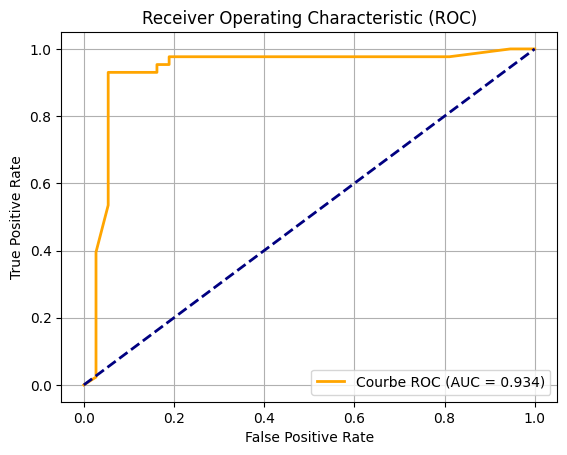

In [26]:
def roc_curve(y_true, y_score):
    thresholds = np.linspace(1, 0, 200)
    TPR = []
    FPR = []

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
        
        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        
        TPR.append(tpr)
        FPR.append(fpr)

    return TPR, FPR, thresholds

TPR, FPR, thresholds = roc_curve(y_test, y_score)

# Calcul de l'AUC via la méthode des trapèzes de NumPy
auc = np.trapezoid(TPR, FPR)

plt.plot(FPR, TPR, color='orange', lw=2, label=f'Courbe ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### VI.3. Tracé de la ROC

🧠 **Cellule Python**


In [27]:
TPR, FPR, thresholds = roc_curve(y_test, y_score)

# TODO
plt.Figure(figsize=(5, 4))
None

#### VI.4. Calcul de l'AUC

L’**AUC** (Area Under the Curve) mesure l’aire sous la courbe ROC.  


##### **Interprétation**

Plus L’**AUC** est proche de **1**, meilleur est le modèle :

- AUC ≈ 1 : excellent
- AUC ≈ 0.5 : aléatoire
- AUC < 0.5 : mauvais

🧠 **Cellule Python**


In [28]:
import scipy.integrate as integr
auc = integr.trapezoid(TPR, FPR)
print("AUC =", auc)

AUC = 0.9340037712130734
